<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/01_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# BLOK 1 — ORTAM VE TEMEL KÜTÜPHANELER
# Amaç: PyTorch ve temel Python kütüphanelerini yüklemek,
#       kullanılacak işlemciyi (CPU/GPU) belirlemek.
# ============================================================

import time                         # time: işlem/eğitim süresini ölçmek için
import random                       # random: Python rastgeleliğini kontrol etmek için
import numpy as np                  # NumPy: sayısal dizi ve matematik işlemleri için

import torch                         # PyTorch: yapay sinir ağını kurmak ve çalıştırmak için
import torch.nn as nn                # torch.nn: neural network (sinir ağı) katmanlarını oluşturmak için
import torch.optim as optim          # torch.optim: model ağırlıklarını optimize etmek için

# PyTorch ve GPU durumunu kontrol ediyoruz
print("PyTorch version:", torch.__version__)   # Kullanılan PyTorch sürümünü gösterir
print("CUDA available:", torch.cuda.is_available())  # GPU kullanılabilir mi kontrol eder

# Modelin çalışacağı işlem birimini belirliyoruz
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)                                               # GPU varsa CUDA, yoksa CPU kullanılır

print("Device:", device)                        # Modelin hangi cihazda çalışacağını gösterir

PyTorch version: 2.11.0+cpu
CUDA available: False
Device: cpu


In [3]:
# ============================================================
# BLOK 2 — RANDOM SEED (RASTGELELİK TOHUMU)
# Amaç: Deneyin tekrarlanabilir (reproducible) olmasını sağlamak.
# ============================================================

SEED = 42                              # Deney boyunca kullanacağımız sabit seed

random.seed(SEED)                      # Python random işlemlerinin seed'ini belirler
np.random.seed(SEED)                   # NumPy rastgeleliğinin seed'ini belirler
torch.manual_seed(SEED)                # PyTorch CPU rastgeleliğinin seed'ini belirler

print("Random seed:", SEED)             # Kullanılan seed değerini kontrol eder

Random seed: 42


In [4]:
# ============================================================
# BLOK 3 — MNIST DATASET (VERİ SETİ)
# Amaç: MNIST el yazısı rakam veri setini yüklemek.
#       Model bu verileri kullanarak rakamları sınıflandıracak.
# ============================================================

from torchvision import datasets                 # Hazır görüntü veri setlerini çağırmak için
from torchvision import transforms               # Görüntülere dönüşüm uygulamak için

# Görüntüleri PyTorch Tensor formatına dönüştürüyoruz
transform = transforms.ToTensor()                 # Piksel değerlerini Tensor'a çevirir

# MNIST eğitim veri setini indiriyor/yüklüyor
train_dataset = datasets.MNIST(
    root="./data",                                # Veri setinin kaydedileceği klasör
    train=True,                                   # Eğitim (training) verisini seç
    download=True,                                # Veri yoksa internetten indir
    transform=transform                           # Belirlediğimiz dönüşümü uygula
)

# MNIST test veri setini indiriyor/yüklüyor
test_dataset = datasets.MNIST(
    root="./data",                                # Veri setinin kaydedileceği klasör
    train=False,                                  # Test verisini seç
    download=True,                                # Veri yoksa internetten indir
    transform=transform                           # Aynı dönüşümü uygula
)

print("Training samples:", len(train_dataset))   # Eğitim örneği sayısını gösterir
print("Test samples:", len(test_dataset))        # Test örneği sayısını gösterir

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.55MB/s]

Training samples: 60000
Test samples: 10000


In [5]:
# ============================================================
# BLOK 4 — MNIST ÖRNEĞİNİ İNCELEME
# Amaç: Veri setindeki tek bir örneğin görüntü boyutunu,
#       etiketini ve Tensor yapısını görmek.
# ============================================================

image, label = train_dataset[0]       # Eğitim setindeki ilk görüntü ve etiket

print("Image shape:", image.shape)    # Görüntünün boyutunu gösterir
print("Label:", label)                # Görüntünün gerçek rakam etiketini gösterir
print("Image type:", type(image))     # Verinin Python/PyTorch tipini gösterir

Image shape: torch.Size([1, 28, 28])
Label: 5
Image type: <class 'torch.Tensor'>


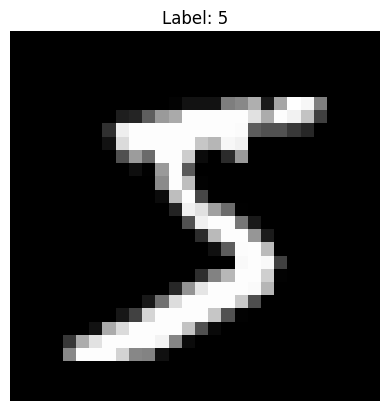

In [6]:
# ============================================================
# BLOK 5 — MNIST GÖRÜNTÜSÜNÜ GÖRSELLEŞTİRME
# Amaç: Tensor olarak yüklediğimiz MNIST görüntüsünü
#       görsel olarak incelemek.
# ============================================================

import matplotlib.pyplot as plt              # Matplotlib: görüntü ve grafik çizmek için

plt.imshow(image.squeeze(), cmap="gray")     # 1×28×28 yapısını 28×28 görüntü olarak gösterir
plt.title(f"Label: {label}")                  # Görüntünün gerçek etiketini başlığa yazar
plt.axis("off")                              # Eksenleri gizler
plt.show()                                   # Görüntüyü ekranda gösterir

In [7]:
# ============================================================
# BLOK 6 — FLATTEN (DÜZLEŞTİRME)
# Amaç: 28×28 piksel görüntüyü 784 elemanlı tek boyutlu
#       bir vektöre dönüştürmek.
# ============================================================

flat_image = image.flatten()                 # 1×28×28 Tensor'u tek boyutlu vektöre çevirir

print("Original shape:", image.shape)        # Görüntünün orijinal boyutunu gösterir
print("Flattened shape:", flat_image.shape)  # Düzleştirilmiş verinin boyutunu gösterir
print("Number of input values:", flat_image.numel())  # Toplam piksel/değer sayısını gösterir

Original shape: torch.Size([1, 28, 28])
Flattened shape: torch.Size([784])
Number of input values: 784


In [8]:
# ============================================================
# BLOK 7 — DATALOADER (VERİ YÜKLEYİCİ)
# Amaç: MNIST verilerini batch (mini grup) halinde modele
#       aktarılabilecek şekilde hazırlamak.
# ============================================================

from torch.utils.data import DataLoader       # PyTorch DataLoader: verileri batch halinde yüklemek için

BATCH_SIZE = 64                                # Her eğitim adımında kullanılacak örnek sayısı

train_loader = DataLoader(
    train_dataset,                             # Kullanacağımız eğitim veri seti
    batch_size=BATCH_SIZE,                      # Her batch'teki görüntü sayısı
    shuffle=True                                # Eğitim verilerini her epoch'ta karıştır
)

test_loader = DataLoader(
    test_dataset,                              # Kullanacağımız test veri seti
    batch_size=BATCH_SIZE,                     # Test batch boyutu
    shuffle=False                              # Test sırasını değiştirme
)

print("Batch size:", BATCH_SIZE)               # Kullanılan batch boyutunu gösterir
print("Number of training batches:", len(train_loader))  # Toplam eğitim batch sayısı
print("Number of test batches:", len(test_loader))       # Toplam test batch sayısı

Batch size: 64
Number of training batches: 938
Number of test batches: 157
